In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
p = "../../data/criminality/Criminality by neighbourhood and district.csv"
df = pd.read_csv(p, sep=";", encoding="utf-8-sig")
df.head()

,ID,WijkenEnBuurten,Gemeentenaam_1,SoortRegio_2,Codering_3,Indelingswijziging_4,AantalInwoners_5,TotaalVermogenVernielingEnGeweld_6,TotaalVermogensmisdrijven_7,TotaalDiefstal_8,...,OverigeVernielingTegenOpenbareOrde_21,TotaalGeweldsEnSeksueleMisdrijven_22,Mishandeling_23,BedreigingEnStalking_24,OverigeGeweldsEnSeksueleMisdrijven_25,TotaalVermogenVernielingEnGeweld_26,TotaalVermogensmisdrijven_27,TotaalDiefstalUitWoningSchuurED_28,VernielingMisdrijfTegenOpenbareOrde_29,GeweldsEnSeksueleMisdrijven_30
0,0,GM1680,Aa en Hunze,Gemeente,GM1680,.,25390,423,284,199,...,14,66,26,23,17,17,11,2,2,3
1,1,WK168000,Aa en Hunze,Wijk,WK168000,1,3560,38,22,16,...,1,7,3,3,1,11,6,1,2,2
2,2,BU16800000,Aa en Hunze,Buurt,BU16800000,1,3415,37,21,15,...,1,7,3,3,1,11,6,1,2,2
3,3,BU16800009,Aa en Hunze,Buurt,BU16800009,1,145,1,1,1,...,0,0,0,0,0,7,7,0,0,0
4,4,WK168001,Aa en Hunze,Wijk,WK168001,1,1430,19,16,12,...,0,2,1,0,1,13,11,2,1,1


In [4]:
df = df.replace(".", np.nan)
for c in df.columns:
    if c in ["WijkenEnBuurten","Gemeentenaam_1","SoortRegio_2","Codering_3","Indelingswijziging_4"]:
        continue
    df[c] = pd.to_numeric(df[c], errors="coerce")
df.dtypes.head(12)

ID                                      int64
WijkenEnBuurten                        object
Gemeentenaam_1                         object
SoortRegio_2                           object
Codering_3                             object
Indelingswijziging_4                   object
AantalInwoners_5                        int64
TotaalVermogenVernielingEnGeweld_6    float64
TotaalVermogensmisdrijven_7           float64
TotaalDiefstal_8                      float64
Fietsendiefstal_9                     float64
DiefstalOverigeVervoermiddelen_10     float64
dtype: object

In [5]:
df.shape, df["SoortRegio_2"].value_counts(dropna=False).head(20)

((16771, 32),
 SoortRegio_2
 Buurt       13305
 Wijk         3086
 Gemeente      380
 Name: count, dtype: int64)

In [6]:
translations = {
    'WijkenEnBuurten': 'DistrictsAndNeighborhoods',
    'Gemeentenaam_1': 'MunicipalityName',
    'SoortRegio_2': 'RegionType',
    'Codering_3': 'RegionCode',
    'Indelingswijziging_4': 'BoundaryChange',
    'AantalInwoners_5': 'Population',
    'TotaalVermogenVernielingEnGeweld_6': 'TotalPropertyDamageAndViolence_Index',
    'TotaalVermogensmisdrijven_7': 'TotalPropertyCrimes',
    'TotaalDiefstal_8': 'TotalTheft',
    'Fietsendiefstal_9': 'BicycleTheft',
    'DiefstalOverigeVervoermiddelen_10': 'TheftOtherVehicles',
    'DiefstalUitVanafVervoermiddelen_11': 'TheftFromVehicles',
    'ZakkenrollerijStraatroofEnBeroving_12': 'PickpocketingAndRobbery',
    'TotaalDiefstalUitWoningSchuurED_13': 'TotalTheftHomeShedEtc',
    'DiefstalUitNietResidentieleGebouwen_14': 'TheftNonResidentialBuildings',
    'OverigeDiefstalInbraak_15': 'OtherTheftBurglary',
    'OverigeVermogensmisdrijven_16': 'OtherPropertyCrimes',
    'TotaalVernielingTegenOpenbareOrde_17': 'TotalVandalismPublicOrder',
    'TotaalVernieling_18': 'TotalVandalism',
    'VernielingAanAuto_19': 'CarVandalism',
    'OverigeVernieling_20': 'OtherVandalism',
    'OverigeVernielingTegenOpenbareOrde_21': 'OtherPublicOrderVandalism',
    'TotaalGeweldsEnSeksueleMisdrijven_22': 'TotalViolentAndSexualCrimes',
    'Mishandeling_23': 'Assault',
    'BedreigingEnStalking_24': 'ThreatsAndStalking',
    'OverigeGeweldsEnSeksueleMisdrijven_25': 'OtherViolentAndSexualCrimes',
    # Note: 26-30 seem to be per-1000-inhabitant rates or repeats in these datasets
    'TotaalVermogenVernielingEnGeweld_26': 'TotalPropertyDamageAndViolence_Rate',
    'TotaalVermogensmisdrijven_27': 'TotalPropertyCrimes_Rate',
    'TotaalDiefstalUitWoningSchuurED_28': 'TotalTheftHomeShed_Rate',
    'VernielingMisdrijfTegenOpenbareOrde_29': 'VandalismPublicOrder_Rate',
    'GeweldsEnSeksueleMisdrijven_30': 'ViolentAndSexualCrimes_Rate'
}

# Apply the translation
df.rename(columns=translations, inplace=True)

# Verify the changes
print(df.columns)

Index(['ID', 'DistrictsAndNeighborhoods', 'MunicipalityName', 'RegionType',
       'RegionCode', 'BoundaryChange', 'Population',
       'TotalPropertyDamageAndViolence_Index', 'TotalPropertyCrimes',
       'TotalTheft', 'BicycleTheft', 'TheftOtherVehicles', 'TheftFromVehicles',
       'PickpocketingAndRobbery', 'TotalTheftHomeShedEtc',
       'TheftNonResidentialBuildings', 'OtherTheftBurglary',
       'OtherPropertyCrimes', 'TotalVandalismPublicOrder', 'TotalVandalism',
       'CarVandalism', 'OtherVandalism', 'OtherPublicOrderVandalism',
       'TotalViolentAndSexualCrimes', 'Assault', 'ThreatsAndStalking',
       'OtherViolentAndSexualCrimes', 'TotalPropertyDamageAndViolence_Rate',
       'TotalPropertyCrimes_Rate', 'TotalTheftHomeShed_Rate',
       'VandalismPublicOrder_Rate', 'ViolentAndSexualCrimes_Rate'],
      dtype='object')


In [7]:
na = df.isna().mean().sort_values(ascending=False)
na.head(20), na.tail(10)

(TotalTheftHomeShed_Rate                 0.105420
 TotalPropertyCrimes_Rate                0.104824
 VandalismPublicOrder_Rate               0.104824
 TotalPropertyDamageAndViolence_Rate     0.104824
 ViolentAndSexualCrimes_Rate             0.104824
 OtherTheftBurglary                      0.053366
 TheftNonResidentialBuildings            0.051160
 TotalTheftHomeShedEtc                   0.043766
 TheftFromVehicles                       0.041381
 TotalVandalismPublicOrder               0.041381
 TotalPropertyDamageAndViolence_Index    0.041381
 PickpocketingAndRobbery                 0.041381
 TotalTheft                              0.041381
 TotalPropertyCrimes                     0.041381
 BicycleTheft                            0.041381
 TheftOtherVehicles                      0.041381
 TotalViolentAndSexualCrimes             0.041381
 OtherPublicOrderVandalism               0.041381
 OtherVandalism                          0.041381
 CarVandalism                            0.041381


In [8]:
num = df.select_dtypes(include=["number"])
num.describe().T.sort_values("mean", ascending=False).head(15)

,count,mean,std,min,25%,50%,75%,max
ID,16771.0,8385.000000,4841.515018,0.0,4192.5,8385.0,12577.5,16770.0
Population,16771.0,3072.585952,12889.724132,0.0,230.0,955.0,2475.0,854047.0
TotalPropertyDamageAndViolence_Index,16077.0,116.291099,799.766678,0.0,8.0,26.0,78.0,71295.0
TotalPropertyCrimes,16077.0,84.170492,613.774079,0.0,6.0,18.0,54.0,56926.0
TotalTheft,16077.0,69.828264,541.209911,0.0,4.0,13.0,43.0,50984.0
TotalPropertyDamageAndViolence_Rate,15013.0,51.917671,193.001021,0.0,14.0,23.0,39.0,9385.0
TotalPropertyCrimes_Rate,15013.0,39.092453,164.862570,0.0,10.0,16.0,28.0,8262.0
TotalVandalismPublicOrder,16077.0,17.040119,94.454862,0.0,1.0,4.0,13.0,6880.0
TotalViolentAndSexualCrimes,16077.0,15.080488,97.262141,0.0,1.0,3.0,10.0,7489.0
OtherPropertyCrimes,16077.0,14.342228,75.225522,0.0,1.0,4.0,11.0,5942.0


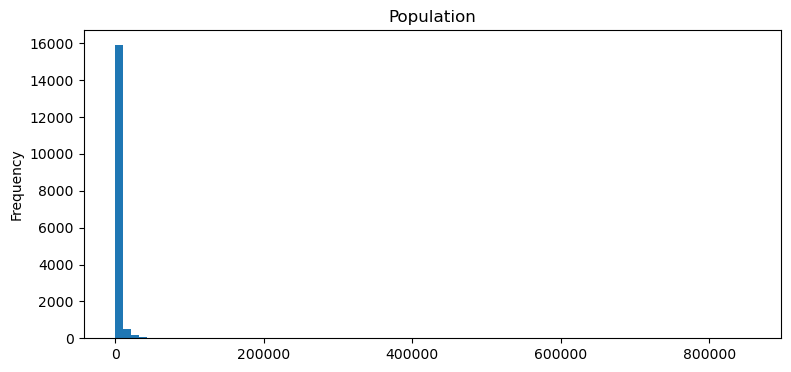

In [9]:
c = "Population"
plt.figure(figsize=(9,4))
df[c].dropna().plot(kind="hist", bins=80)
plt.title(c)
plt.show()

Text(0.5, 1.0, 'Correlation: Population vs Property Crime')

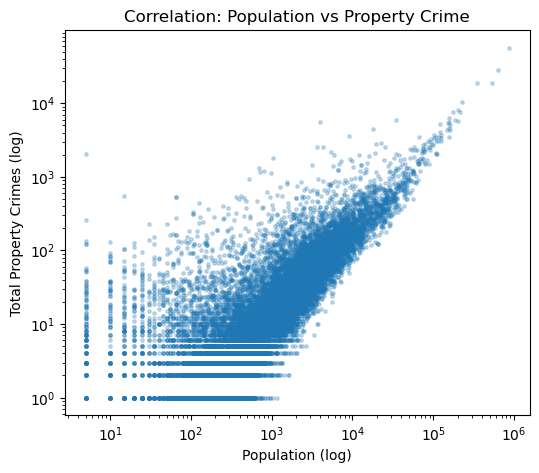

In [10]:
x = df["Population"]
y = df["TotalPropertyCrimes"]

m = x.notna() & y.notna()

plt.figure(figsize=(6, 5))
plt.scatter(x[m], y[m], s=6, alpha=0.25)

plt.xscale("log")
plt.yscale("log")

# Add labels
plt.xlabel("Population (log)")
plt.ylabel("Total Property Crimes (log)")
plt.title("Correlation: Population vs Property Crime")

In [ ]:
from pathlib import Path
out_csv = Path("../../data/processed/criminality.csv")  

df.to_csv(out_csv, index=False)